<a href="https://colab.research.google.com/github/maycongsouzaeng-pixel/LAMET-UENF-Maycon/blob/main/secas_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova seção

In [ ]:

%pip install cdsapi
%pip install netcdf4

import cdsapi

dataset = "derived-drought-historical-monthly"
request = {
    "variable": [
        "standardised_precipitation_evapotranspiration_index",
        "probability_of_zero_precipitation_spi",
        "test_for_normality_spi",
        "test_for_normality_spei"
    ],
    "accumulation_period": [
        "1",
        "3",
        "6",
        "12",
        "24",
        "36",
        "48"
    ],
    "version": "1_0",
    "product_type": ["reanalysis"],
    "dataset_type": "consolidated_dataset",
    "year": [
        "2024"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "area": [-22.15, -42.15, -22.55, -41.55]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
key='a36b9d34-17f4-4978-ac4f-eb55037375d0', verify=False)
client.retrieve(dataset, request).download()


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-06-30 18:46:34,119 INFO Request 

71abd5e9594cb1540e8bddd6dc53d1ee.zip:   0%|          | 0.00/8.26M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'71abd5e9594cb1540e8bddd6dc53d1ee.zip'

In [ ]:
import zipfile
import os

zip_file_path = '/content/71abd5e9594cb1540e8bddd6dc53d1ee.zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted all files to: {extract_dir}")

# List the extracted files to see what we have
print("Files after extraction:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))


Extracted all files to: /content/extracted_data
Files after extraction:
/content/extracted_data/SPI36_spipzero_gamma_global_era5_moda_ref1991to2020_05.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI36_genlogistic_global_era5_moda_ref1991to2020_202407.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI1_spisignificance_gamma_global_era5_moda_ref1991to2020_11.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI24_genlogistic_global_era5_moda_ref1991to2020_202401.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI12_spipzero_gamma_global_era5_moda_ref1991to2020_08.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI24_speisignificance_genlogistic_global_era5_moda_ref1991to2020_04.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI6_spipzero_gamma_global_era5_moda_ref1991to2020_10.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI48_spisignificance_gamm

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.plot import show
import geopandas as gpd

extract_dir = "/content/extracted_data"

# Procurar arquivos
tifs = glob.glob(os.path.join(extract_dir, "**", "*.tif"), recursive=True)
shps = glob.glob(os.path.join(extract_dir, "**", "*.shp"), recursive=True)

print("GeoTIFFs encontrados:", tifs)
print("Shapefiles encontrados:", shps)

GeoTIFFs encontrados: []
Shapefiles encontrados: []


In [ ]:
import zipfile
import os

zip_file_path = '/content/13e5e4b9742e2233354be7c3be8b589b.zip' # Updated to the latest downloaded zip file
et_extract_dir = '/content/extracted_data/et_data' # Modified to extract to a specific subdirectory for ET data

# Create the extraction directory if it doesn't exist
os.makedirs(et_extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(et_extract_dir)

print(f"Extracted all ET files to: {et_extract_dir}")

# List the extracted files to see what we have
print("ET Files after extraction:")
for root, dirs, files in os.walk(et_extract_dir):
    for file in files:
        print(os.path.join(root, file))

Extracted all ET files to: /content/extracted_data/et_data
ET Files after extraction:
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250622_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250822_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250803_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250708_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250914_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250926_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/et

In [ ]:
import zipfile
import os

zip_file_path = '/content/71abd5e9594cb1540e8bddd6dc53d1ee.zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted all files to: {extract_dir}")

# List the extracted files to see what we have
print("Files after extraction:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))


Extracted all files to: /content/extracted_data
Files after extraction:
/content/extracted_data/SPI36_spipzero_gamma_global_era5_moda_ref1991to2020_05.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI36_genlogistic_global_era5_moda_ref1991to2020_202407.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI1_spisignificance_gamma_global_era5_moda_ref1991to2020_11.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI24_genlogistic_global_era5_moda_ref1991to2020_202401.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI12_spipzero_gamma_global_era5_moda_ref1991to2020_08.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPEI24_speisignificance_genlogistic_global_era5_moda_ref1991to2020_04.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI6_spipzero_gamma_global_era5_moda_ref1991to2020_10.area-subset.-22.15.-41.55.-22.55.-42.15.nc
/content/extracted_data/SPI48_spisignificance_gamm

Loading file: /content/extracted_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250622_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
Dataset loaded successfully:
<xarray.Dataset> Size: 196B
Dimensions:                           (time: 1, lat: 5, lon: 5)
Coordinates:
  * time                              (time) datetime64[ns] 8B 2025-06-22
  * lat                               (lat) float64 40B -1.8 -1.9 -2.0 -2.1 -2.2
  * lon                               (lon) float64 40B -49.1 -49.0 ... -48.7
Data variables:
    ReferenceET_PenmanMonteith_FAO56  (time, lat, lon) float32 100B ...
    crs                               (time) int64 8B ...
Attributes:
    Conventions:  CF-1.7
    title:        AgERA5 daily weather variables derived from the ECMWF ERA5 ...
    institution:  Wageningen Environmental Research
    history:      Generated by `pragera5 run_daily_processing 2025-06-22` ver...
    references:   https://doi.org/10.24381/cds.6c68c9bb
    source:       ECWMF ER

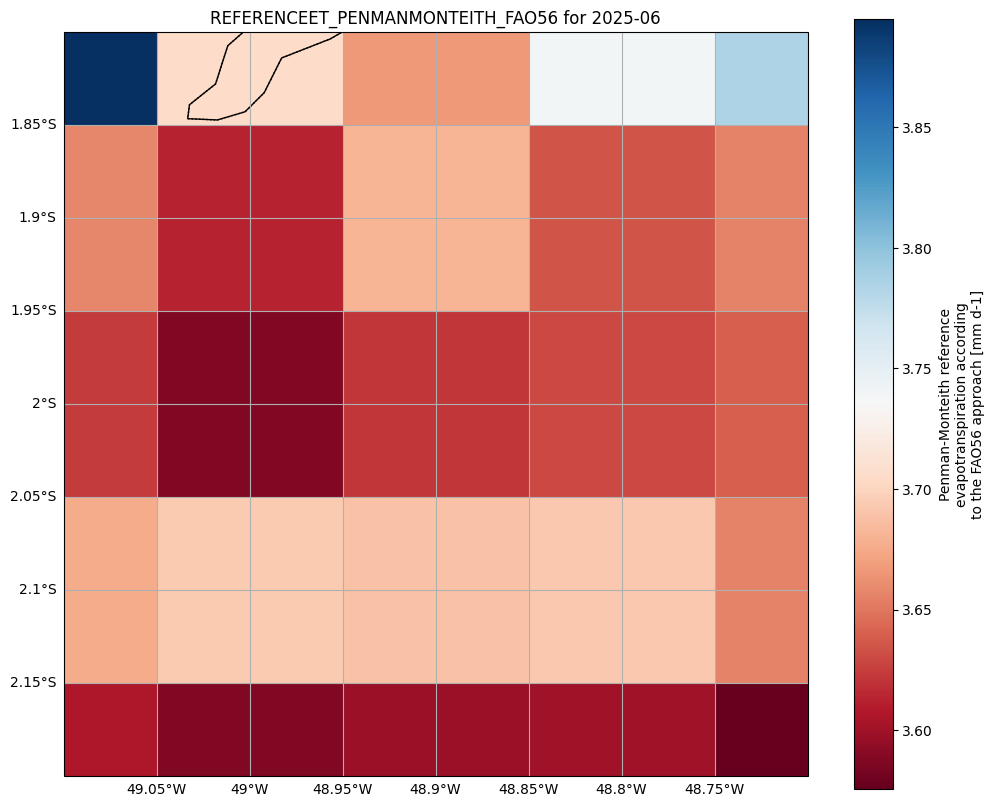

In [ ]:
%pip install h5netcdf
%pip install netcdf4
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

# Choose one of the extracted NetCDF files to load
# Dynamically find the first .nc file in the extracted_data directory
extracted_nc_files = glob.glob('/content/extracted_data/*.nc')

if extracted_nc_files:
    file_to_load = extracted_nc_files[0]
    print(f"Loading file: {file_to_load}")
else:
    print("No .nc files found in /content/extracted_data. Please ensure data is downloaded and extracted correctly.")
    file_to_load = None # Set to None to prevent further execution if no file is found

if file_to_load:
    # Load the dataset using the 'h5netcdf' engine for .nc files
    try:
        ds = xr.open_dataset(file_to_load, engine='h5netcdf')
        print("Dataset loaded successfully:")
        print(ds)
        print("\nDataset Data Variables:", ds.data_vars)
        print("Dataset Coordinates:", ds.coords)

        # Plotting a variable from the dataset
        # You might need to adjust the variable name based on the actual dataset content
        # Let's assume the main variable is 'spei' or similar
        # We'll try to find a suitable variable if 'spei' isn't present
        plot_variable = None
        if 'spei' in ds.data_vars:
            plot_variable = 'spei'
        elif len(ds.data_vars) > 0:
            # Pick the first data variable if 'spei' is not found
            plot_variable = list(ds.data_vars.keys())[0]
            print(f"'spei' variable not found, plotting '{plot_variable}' instead.")
        else:
            print("No data variables found in the dataset to plot.")

        if plot_variable:
            plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=ccrs.PlateCarree())

            # Ensure 'longitude' and 'latitude' are correctly named in the dataset
            x_coord = 'longitude' if 'longitude' in ds.coords else 'lon'
            y_coord = 'latitude' if 'latitude' in ds.coords else 'lat'

            if x_coord in ds.coords and y_coord in ds.coords:
                ds[plot_variable].isel(time=0).plot.pcolormesh(ax=ax, cmap='RdBu', transform=ccrs.PlateCarree(), x=x_coord, y=y_coord)

                ax.add_feature(cfeature.LAND, edgecolor='black')
                ax.add_feature(cfeature.OCEAN)
                ax.add_feature(cfeature.COASTLINE)
                ax.add_feature(cfeature.BORDERS, linestyle=':')
                ax.add_feature(cfeature.STATES, linestyle=':')

                ax.set_extent([
                    ds[x_coord].min().item(),
                    ds[x_coord].max().item(),
                    ds[y_coord].min().item(),
                    ds[y_coord].max().item()
                ], crs=ccrs.PlateCarree())

                gl = ax.gridlines(draw_labels=True)
                gl.top_labels = False
                gl.right_labels = False

                plt.title(f"{plot_variable.upper()} for {ds['time'].isel(time=0).dt.strftime('%Y-%m').item()}")
                plt.savefig('spei36_plot.png') # Save the figure
                plt.show()
            else:
                print(f"Could not find '{x_coord}' or '{y_coord}' coordinates in the dataset for plotting.")


    except Exception as e:
        print(f"Error loading or plotting dataset: {e}")
        print("Please check if the file path and variable name are correct.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 45.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

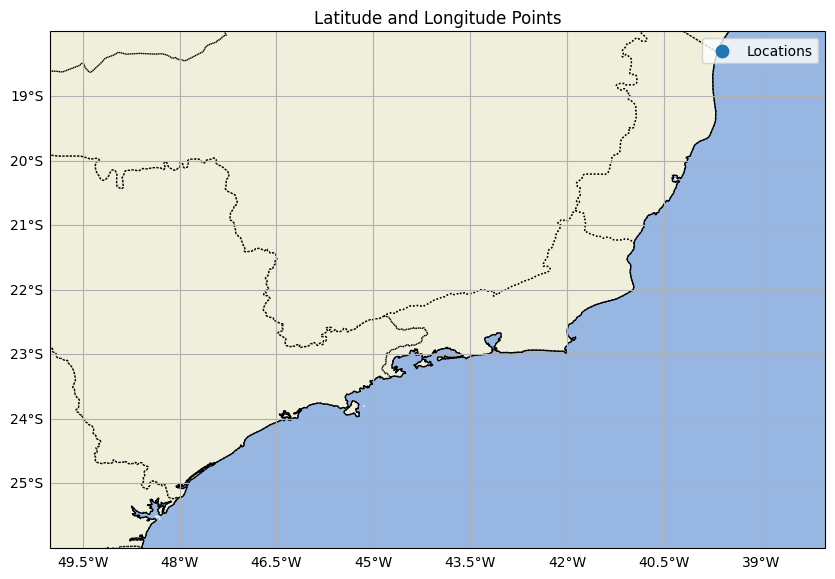

In [ ]:
!pip install cartopy
import cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example latitude and longitude data
latitudes = [-01.75, -2.25]
longitudes = [-49.20, -48.70]

# Create figure
plt.figure(figsize=(10, 8))

# Map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot points
ax.scatter(
    longitudes,
    latitudes,
    s=80,
    marker='o',
    transform=ccrs.PlateCarree(),
    label='Locations'
)

# Define map extent: [min_lon, max_lon, min_lat, max_lat]
ax.set_extent([-50, -38, -26, -18], crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Title and legend
plt.title("Latitude and Longitude Points")
plt.legend()

plt.show()

In [ ]:
import cdsapi

dataset = "sis-agrometeorological-indicators"
request = {
    "variable": "reference_evapotranspiration",
    "year": ["2025"],
    "month": [
        "06", "07", "08",
        "09"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "version": "2_0",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
key='a36b9d34-17f4-4978-ac4f-eb55037375d0', verify=False)
client.retrieve(dataset, request).download()

ModuleNotFoundError: No module named 'cdsapi'

In [ ]:
%pip install cdsapi
import cdsapi

dataset = "sis-agrometeorological-indicators"
request = {
    "variable": "reference_evapotranspiration",
    "year": ["2025"],
    "month": [
        "06", "07", "08",
        "09"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "version": "2_0",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
key='a36b9d34-17f4-4978-ac4f-eb55037375d0', verify=False)
client.retrieve(dataset, request).download()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-01 16:18:36,560 INFO [2026-06

13e5e4b9742e2233354be7c3be8b589b.zip:   0%|          | 0.00/3.02M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'13e5e4b9742e2233354be7c3be8b589b.zip'

Processando arquivo: /content/extracted_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250622_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
Média: 3.66
Mínimo: 3.58
Máximo: 3.89
Desvio padrão: 0.07


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


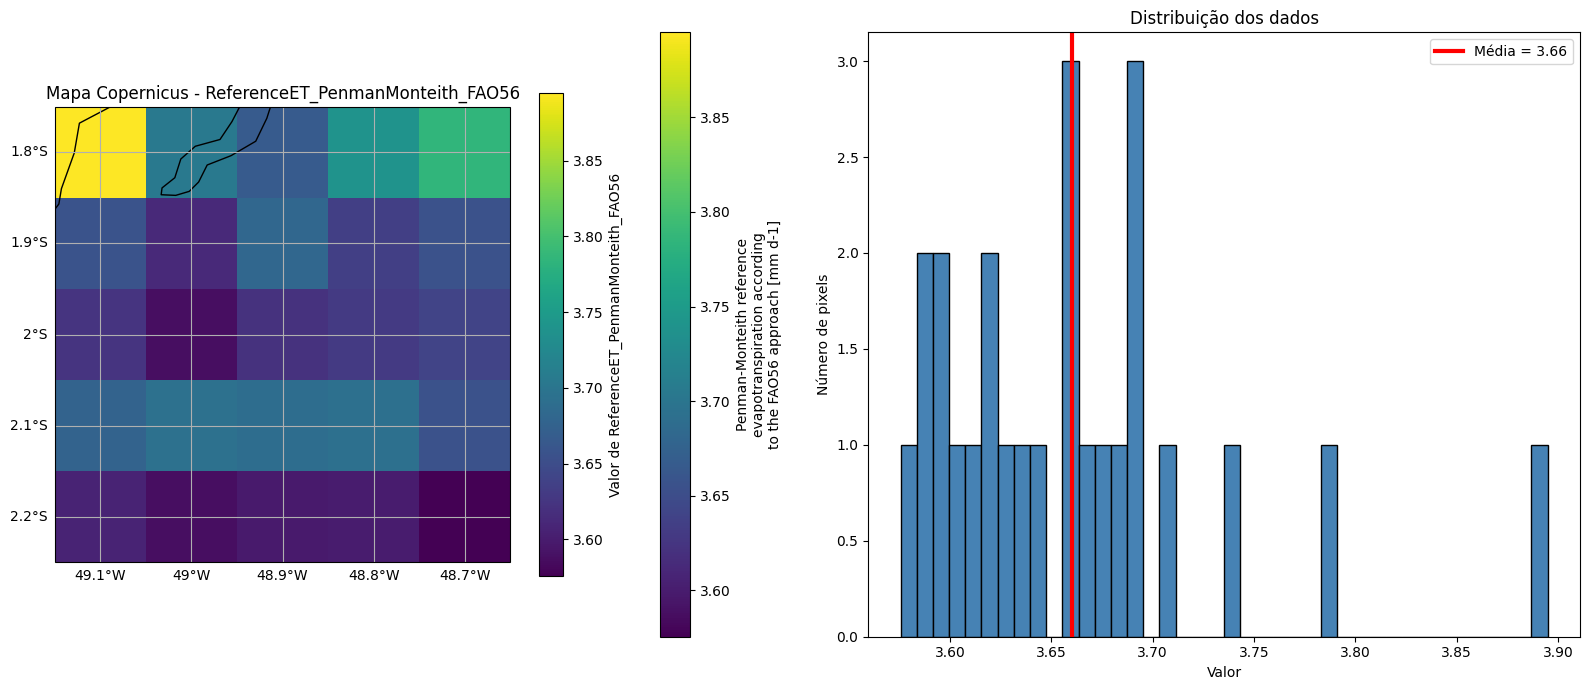

In [ ]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

extract_dir = "/content/extracted_data"

# Localizar o primeiro arquivo NetCDF
files_to_process = glob.glob(os.path.join(extract_dir, "**", "*.nc"), recursive=True)

if files_to_process:
    arquivo = files_to_process[0]
    print(f"Processando arquivo: {arquivo}")

    try:
        ds = xr.open_dataset(arquivo, engine='h5netcdf')

        # Tentar encontrar uma variável para plotar, preferindo 'spei' ou a primeira disponível
        plot_variable = None
        if 'spei' in ds.data_vars:
            plot_variable = 'spei'
        elif 'ReferenceET_PenmanMonteith_FAO56' in ds.data_vars: # Assuming this is the variable from the last output
            plot_variable = 'ReferenceET_PenmanMonteith_FAO56'
        elif len(ds.data_vars) > 0:
            plot_variable = list(ds.data_vars.keys())[0]

        if plot_variable:
            # Extrair os dados para cálculo e plotagem
            # Pegar o primeiro timestamp para uma plotagem 2D
            data_to_plot = ds[plot_variable].isel(time=0).values

            # Estatísticas
            media = np.nanmean(data_to_plot)
            minimo = np.nanmin(data_to_plot)
            maximo = np.nanmax(data_to_plot)
            desvio = np.nanstd(data_to_plot)

            print(f"Média: {media:.2f}")
            print(f"Mínimo: {minimo:.2f}")
            print(f"Máximo: {maximo:.2f}")
            print(f"Desvio padrão: {desvio:.2f}")

            # Criar figura
            fig = plt.figure(figsize=(16,7))

            ###########################################
            # MAPA
            ###########################################
            ax = fig.add_subplot(121, projection=ccrs.PlateCarree())

            # Coordenadas 'longitude' e 'latitude'
            x_coord = 'lon' if 'lon' in ds.coords else 'longitude'
            y_coord = 'lat' if 'lat' in ds.coords else 'latitude'

            if x_coord in ds.coords and y_coord in ds.coords:
                ds[plot_variable].isel(time=0).plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree(), x=x_coord, y=y_coord)
            else:
                print(f"Could not find '{x_coord}' or '{y_coord}' coordinates in the dataset for plotting.")
                # Fallback plotting if coords not found or not suitable for pcolormesh
                # This might need more sophisticated handling depending on the data structure
                # For now, we'll just plot it as a raw image if coordinates are problematic.
                ax.imshow(
                    data_to_plot,
                    origin="upper",
                    cmap="viridis",
                    transform=ccrs.PlateCarree()
                )


            ax.coastlines(resolution='10m')
            ax.add_feature(cfeature.BORDERS)
            ax.add_feature(cfeature.RIVERS)
            ax.add_feature(cfeature.LAKES)

            gl = ax.gridlines(draw_labels=True)
            gl.top_labels=False
            gl.right_labels=False

            plt.colorbar(ax.collections[0] if ax.collections else None,
                         ax=ax,
                         shrink=0.8,
                         label=f"Valor de {plot_variable}")

            plt.title(f"Mapa Copernicus - {plot_variable}")

            ###########################################
            # HISTOGRAMA (Distribuição dos valores)
            ###########################################
            ax2 = fig.add_subplot(122)

            ax2.hist(
                data_to_plot.flatten(),
                bins=40,
                color="steelblue",
                edgecolor="black"
            )

            ax2.axvline(media,
                        color="red",
                        linewidth=3,
                        label=f"Média = {media:.2f}")

            ax2.set_xlabel("Valor")
            ax2.set_ylabel("Número de pixels")
            ax2.set_title("Distribuição dos dados")
            ax2.legend()

            plt.tight_layout()
            plt.show()
        else:
            print("Nenhuma variável de dados encontrada no conjunto de dados para plotagem.")

    except Exception as e:
        print(f"Erro ao carregar ou plotar o conjunto de dados: {e}")
        print("Verifique se o caminho do arquivo e o nome da variável estão corretos.")
else:
    print("Nenhum arquivo .nc encontrado em /content/extracted_data. Verifique se os dados foram baixados e extraídos corretamente.")

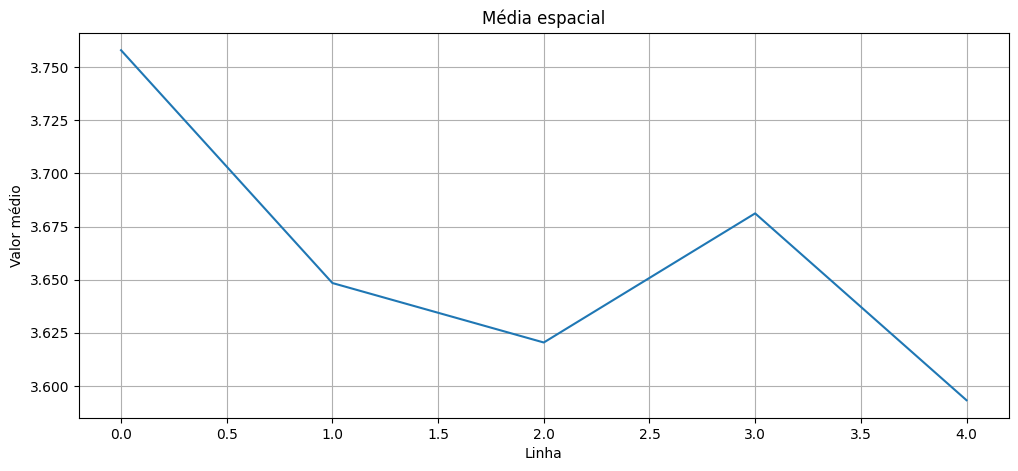

In [ ]:
media_linhas = np.nanmean(data_to_plot, axis=1)

plt.figure(figsize=(12,5))
plt.plot(media_linhas)
plt.grid(True)
plt.xlabel("Linha")
plt.ylabel("Valor médio")
plt.title("Média espacial")
plt.show()

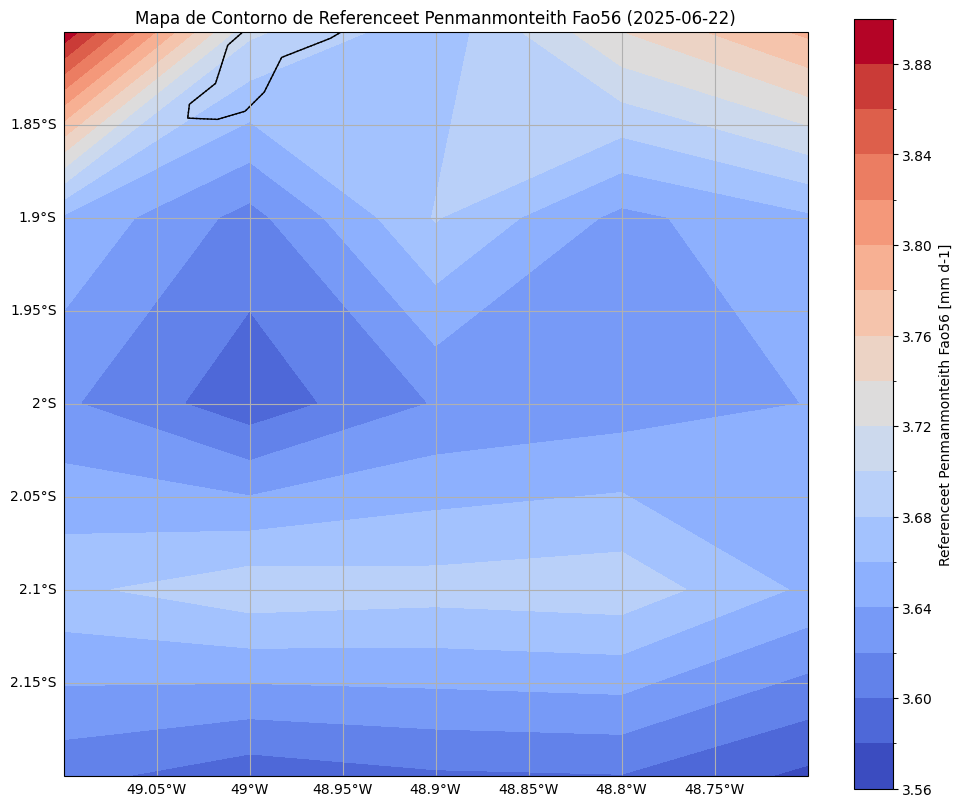

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Certificar-se de que ds e plot_variable estão disponíveis do código anterior
if 'ds' in locals() and 'plot_variable' in locals() and plot_variable:
    plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plotar o mapa de contorno
    # x_coord e y_coord já foram definidos no código anterior
    ds[plot_variable].isel(time=0).plot.contourf(
        ax=ax,
        cmap='coolwarm',
        levels=20, # Número de níveis de contorno
        transform=ccrs.PlateCarree(),
        x=x_coord,
        y=y_coord,
        cbar_kwargs={'label': f'{plot_variable.replace("_", " ").title()} [mm d-1]'}
    )

    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':')

    # Definir a extensão do mapa para a área total dos dados carregados
    ax.set_extent([
        ds[x_coord].min().item(),
        ds[x_coord].max().item(),
        ds[y_coord].min().item(),
        ds[y_coord].max().item()
    ], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    plt.title(f'Mapa de Contorno de {plot_variable.replace("_", " ").title()} ({ds["time"].isel(time=0).dt.strftime("%Y-%m-%d").item()})')
    plt.show()
else:
    print("Variáveis 'ds' ou 'plot_variable' não encontradas. Certifique-se de que os dados foram carregados e a variável de plotagem foi identificada.")

### Análise Mensal dos Dados

Agora vamos carregar todos os arquivos NetCDF extraídos, extrair a variável de interesse e agrupar os dados por mês para calcular a média mensal.

In [ ]:
import os
import glob
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

extract_dir = "/content/extracted_data"

# Localizar todos os arquivos NetCDF
all_nc_files = glob.glob(os.path.join(extract_dir, "**", "*.nc"), recursive=True)

monthly_data = []

if all_nc_files:
    print(f"Encontrados {len(all_nc_files)} arquivos .nc para processar.")
    for nc_file in all_nc_files:
        try:
            ds = xr.open_dataset(nc_file, engine='h5netcdf')

            # Obter a variável de interesse, que identificamos como 'ReferenceET_PenmanMonteith_FAO56'
            # ou 'spei', ou a primeira variável de dados disponível.
            plot_variable = None
            if 'ReferenceET_PenmanMonteith_FAO56' in ds.data_vars:
                plot_variable = 'ReferenceET_PenmanMonteith_FAO56'
            elif 'spei' in ds.data_vars:
                plot_variable = 'spei'
            elif len(ds.data_vars) > 0:
                plot_variable = list(ds.data_vars.keys())[0]

            if plot_variable and 'time' in ds.coords:
                # Consideramos apenas o primeiro "time" se houver vários, como em dados diários
                date = pd.to_datetime(ds['time'].isel(time=0).item())
                value = ds[plot_variable].isel(time=0).mean().item() # Média espacial para este timestamp
                monthly_data.append({'date': date, 'value': value})
            else:
                print(f"Aviso: Nenhuma variável de plotagem ou coordenada de tempo encontrada em {nc_file}")
        except Exception as e:
            print(f"Erro ao carregar ou processar {nc_file}: {e}")
else:
    print("Nenhum arquivo .nc encontrado em /content/extracted_data.")

# Criar DataFrame
df_monthly = pd.DataFrame(monthly_data)

if not df_monthly.empty:
    # Extrair ano e mês
    df_monthly['year'] = df_monthly['date'].dt.year
    df_monthly['month'] = df_monthly['date'].dt.month

    # Agrupar por ano e mês e calcular a média
    monthly_avg = df_monthly.groupby(['year', 'month'])['value'].mean().reset_index()
    monthly_avg['month_year'] = pd.to_datetime(monthly_avg['year'].astype(str) + '-' + monthly_avg['month'].astype(str))
    monthly_avg = monthly_avg.sort_values('month_year')

    print("Médias mensais calculadas:")
    display(monthly_avg.head())
else:
    print("Nenhum dado mensal para processar.")

Encontrados 122 arquivos .nc para processar.
Médias mensais calculadas:


,year,month,value,month_year
0,2025,6,3.799108,2025-06-01
1,2025,7,4.034914,2025-07-01
2,2025,8,4.378722,2025-08-01
3,2025,9,4.947774,2025-09-01


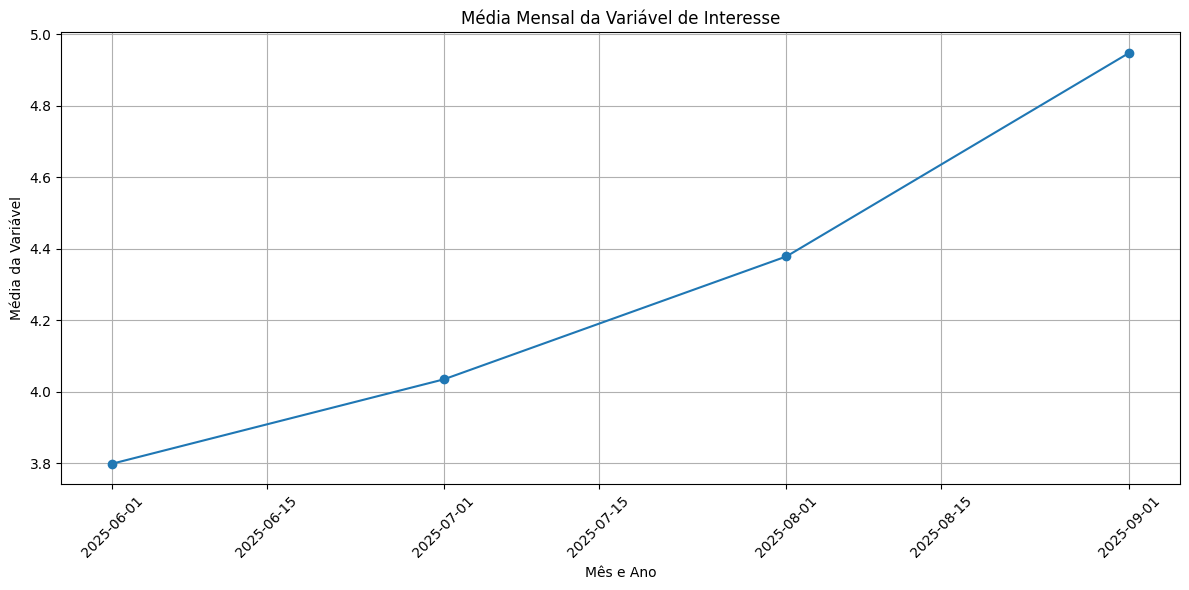

In [ ]:
if not df_monthly.empty:
    # Plotar a média mensal
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_avg['month_year'], monthly_avg['value'], marker='o', linestyle='-')
    plt.title('Média Mensal da Variável de Interesse')
    plt.xlabel('Mês e Ano')
    plt.ylabel('Média da Variável')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado mensal para plotar.")

In [ ]:
criar um codigo para salvar os dados , graficos e imagens no meu driver_can_create

SyntaxError: invalid syntax (3110461571.py, line 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define o caminho onde o arquivo CSV será salvo no Google Drive
save_path = '/content/drive/MyDrive/monthly_avg.csv'

# Garante que o diretório de destino exista
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Salva o DataFrame como CSV
monthly_avg.to_csv(save_path, index=False)

print(f'DataFrame monthly_avg salvo em: {save_path}')

DataFrame monthly_avg salvo em: /content/drive/MyDrive/monthly_avg.csv


In [ ]:
print("Estatísticas Descritivas do DataFrame monthly_avg:")
display(monthly_avg.describe())

Estatísticas Descritivas do DataFrame monthly_avg:


,year,month,value,month_year
count,4.0,4.000000,4.000000,4
mean,2025.0,7.500000,4.290130,2025-07-16 18:00:00
min,2025.0,6.000000,3.799108,2025-06-01 00:00:00
25%,2025.0,6.750000,3.975963,2025-06-23 12:00:00
50%,2025.0,7.500000,4.206818,2025-07-16 12:00:00
75%,2025.0,8.250000,4.520985,2025-08-08 18:00:00
max,2025.0,9.000000,4.947774,2025-09-01 00:00:00
std,0.0,1.290994,0.498859,NaN


In [ ]:
import cdsapi

dataset = "sis-agrometeorological-indicators"
request = {
    "variable": "2m_temperature",
    "statistic": ["24_hour_mean"],
    "year": ["2025"],
    "month": [
        "06", "07", "08",
        "09"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "version": "2_0",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
 key='a36b9d34-17f4-4978-ac4f-eb55037375d0')
client.retrieve(dataset, request).download()

2026-07-01 16:55:41,869 INFO [2026-06-17T00:00:00] As announced on our [Forum post](https://forum.ecmwf.int/t/agera5-version-1-1-to-be-deprecated-please-use-agera5-version-2-if-not-already/14940), the superseded AgERA5 version 1.1. is no longer updated and will subsequently be deprecated (along with version 1) later this year. AgERA5 v2 remains updated on a daily basis.
INFO:ecmwf.datastores.legacy_client:[2026-06-17T00:00:00] As announced on our [Forum post](https://forum.ecmwf.int/t/agera5-version-1-1-to-be-deprecated-please-use-agera5-version-2-if-not-already/14940), the superseded AgERA5 version 1.1. is no longer updated and will subsequently be deprecated (along with version 1) later this year. AgERA5 v2 remains updated on a daily basis.
2026-07-01 16:55:41,872 INFO Request ID is 675d14b4-7366-48ad-a1bb-b65c0d4e4bef
INFO:ecmwf.datastores.legacy_client:Request ID is 675d14b4-7366-48ad-a1bb-b65c0d4e4bef
2026-07-01 16:55:42,035 INFO status has been updated to accepted
INFO:ecmwf.data

61cfc7e95eee0235a9dfcfdba314d761.zip:   0%|          | 0.00/3.01M [00:00<?, ?B/s]

'61cfc7e95eee0235a9dfcfdba314d761.zip'

In [ ]:
import cdsapi

dataset = "sis-agrometeorological-indicators"
request = {
    "variable": "precipitation_flux",
    "statistic": ["24_hour_mean"],
    "year": ["2025"],
    "month": [
        "06", "07", "08",
        "09"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "version": "2_0",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api',
key='a36b9d34-17f4-4978-ac4f-eb55037375d0')
client.retrieve(dataset, request).download()

2026-07-01 17:06:49,441 INFO [2026-06-17T00:00:00] As announced on our [Forum post](https://forum.ecmwf.int/t/agera5-version-1-1-to-be-deprecated-please-use-agera5-version-2-if-not-already/14940), the superseded AgERA5 version 1.1. is no longer updated and will subsequently be deprecated (along with version 1) later this year. AgERA5 v2 remains updated on a daily basis.
INFO:ecmwf.datastores.legacy_client:[2026-06-17T00:00:00] As announced on our [Forum post](https://forum.ecmwf.int/t/agera5-version-1-1-to-be-deprecated-please-use-agera5-version-2-if-not-already/14940), the superseded AgERA5 version 1.1. is no longer updated and will subsequently be deprecated (along with version 1) later this year. AgERA5 v2 remains updated on a daily basis.
2026-07-01 17:06:49,445 INFO Request ID is 3177ee27-6a13-4ee6-915b-1aedfd978d2c
INFO:ecmwf.datastores.legacy_client:Request ID is 3177ee27-6a13-4ee6-915b-1aedfd978d2c
2026-07-01 17:06:49,606 INFO status has been updated to accepted
INFO:ecmwf.data

fe066a0f0affb1a9c548ed86418879ec.zip:   0%|          | 0.00/2.98M [00:00<?, ?B/s]

'fe066a0f0affb1a9c548ed86418879ec.zip'

In [ ]:
import zipfile
import os

# Caminho para o arquivo zip de temperatura
zip_file_path_temp = '/content/61cfc7e95eee0235a9dfcfdba314d761.zip'
temp_extract_dir = '/content/extracted_data/temp_data' # Modified to extract to a specific subdirectory for temperature data

# Criar o diretório de extração se não existir
os.makedirs(temp_extract_dir, exist_ok=True)

print(f"Extraindo arquivos de temperatura de: {zip_file_path_temp}")
with zipfile.ZipFile(zip_file_path_temp, 'r') as zip_ref:
    zip_ref.extractall(temp_extract_dir)

print(f"Todos os arquivos foram extraídos para: {temp_extract_dir}")

# Listar os arquivos extraídos para confirmar
print("Arquivos de temperatura após a extração:")
found_temp_files = False
for root, dirs, files in os.walk(temp_extract_dir):
    for file in files:
        if 'Temperature-Air-2m' in file and file.endswith('.nc'):
            print(os.path.join(root, file))
            found_temp_files = True

if not found_temp_files:
    print("Nenhum arquivo NetCDF de temperatura foi encontrado após a extração com o padrão 'Temperature-Air-2m'.")

Extraindo arquivos de temperatura de: /content/61cfc7e95eee0235a9dfcfdba314d761.zip
Todos os arquivos foram extraídos para: /content/extracted_data/temp_data
Arquivos de temperatura após a extração:
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250702_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250828_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250920_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250824_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250806_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric

In [ ]:
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

# Caminhos para os diretórios de extração específicos
et_data_dir = "/content/extracted_data/et_data"
temp_data_dir = "/content/extracted_data/temp_data"

# Localizar os arquivos NetCDF para temperatura e evapotranspiração nos seus respectivos diretórios
temp_files = sorted(glob.glob(os.path.join(temp_data_dir, "*Temperature-Air-2m*.nc")))
et_files = sorted(glob.glob(os.path.join(et_data_dir, "*ReferenceET_PenmanMonteith_FAO56*.nc")))

print(f"Found temperature files: {temp_files}")
print(f"Found evapotranspiration files: {et_files}")

if temp_files and et_files:
    # Para simplicidade, vamos usar o primeiro arquivo de cada tipo
    # Em um cenário real, você pode querer iterar ou combinar os dados
    temp_file = temp_files[0]
    et_file = et_files[0]
    print(f"Carregando temperatura de: {temp_file}")
    print(f"Carregando evapotranspiração de: {et_file}")

    try:
        ds_temp = xr.open_dataset(temp_file, engine='h5netcdf')
        ds_et = xr.open_dataset(et_file, engine='h5netcdf')

        # Encontrar a variável de temperatura (provavelmente '2m_temperature')
        # Convert variable names to lowercase for robust matching
        temp_var_name = [v for v in ds_temp.data_vars if 'temperature' in v.lower()][0]
        # Encontrar a variável de evapotranspiração
        # Convert variable names to lowercase for robust matching
        et_var_name = [v for v in ds_et.data_vars if 'referenceet' in v.lower()][0]

        # Selecionar o primeiro timestamp para ambos os datasets
        # e converter para numpy arrays
        temperature_data = ds_temp[temp_var_name].isel(time=0).values.flatten()
        evapotranspiration_data = ds_et[et_var_name].isel(time=0).values.flatten()

        # Alinhar os dados (garantir que tenham o mesmo tamanho, se não, pode precisar de reamostragem)
        # Aqui assumimos que, como foram baixados com a mesma área, terão grades compatíveis
        min_len = min(len(temperature_data), len(evapotranspiration_data))
        temperature_data = temperature_data[:min_len]
        evapotranspiration_data = evapotranspiration_data[:min_len]

        # Remover NaNs para o histograma 2D
        valid_indices = ~np.isnan(temperature_data) & ~np.isnan(evapotranspiration_data)
        temperature_data = temperature_data[valid_indices]
        evapotranspiration_data = evapotranspiration_data[valid_indices]

        if len(temperature_data) > 0:
            plt.figure(figsize=(10, 8))
            plt.hist2d(temperature_data, evapotranspiration_data, bins=30, cmap='viridis')
            plt.colorbar(label='Densidade')
            plt.xlabel(f'{temp_var_name.replace("_", " ").title()} (K)') # Unidade de temperatura em Kelvin
            plt.ylabel(f'{et_var_name.replace("_", " ").title()} (mm d-1)')
            plt.title('Mapa de Calor: Temperatura vs. Evapotranspiração')
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.show()
        else:
            print("Nenhum dado válido para plotar após a remoção de NaNs.")

    except Exception as e:
        print(f"Erro ao carregar ou processar os dados: {e}")
        print("Verifique os nomes das variáveis e os caminhos dos arquivos.")
else:
    print("Arquivos de temperatura ou evapotranspiração não encontrados. Verifique se foram baixados e extraídos corretamente.")


Found temperature files: ['/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250601_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250602_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250603_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250604_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250605_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250606_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', '/content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_2

Plotando dados do arquivo: /content/extracted_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250622_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc


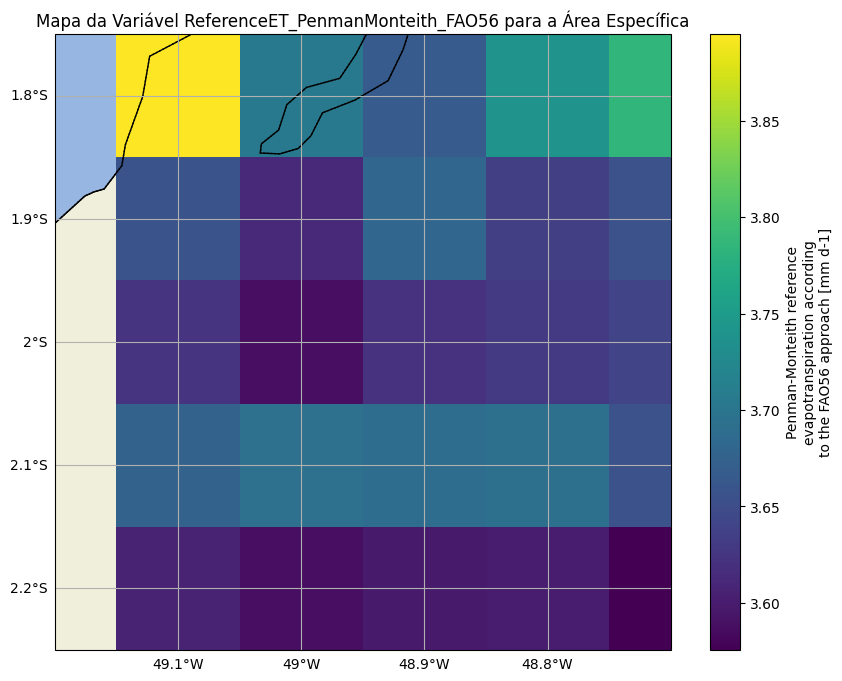

In [ ]:
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

extract_dir = "/content/extracted_data"

# Localizar o primeiro arquivo NetCDF para plotagem
# Você pode ajustar esta lógica se quiser plotar um arquivo específico ou uma agregação
files_to_process = glob.glob(os.path.join(extract_dir, "**", "*.nc"), recursive=True)

if files_to_process:
    # Usar o primeiro arquivo encontrado como exemplo, ou você pode selecionar outro
    file_to_load = files_to_process[0]
    print(f"Plotando dados do arquivo: {file_to_load}")

    try:
        ds = xr.open_dataset(file_to_load, engine='h5netcdf')

        # Tentar encontrar a variável para plotar, preferindo 'ReferenceET_PenmanMonteith_FAO56' ou a primeira disponível
        plot_variable = None
        if 'ReferenceET_PenmanMonteith_FAO56' in ds.data_vars:
            plot_variable = 'ReferenceET_PenmanMonteith_FAO56'
        elif len(ds.data_vars) > 0:
            plot_variable = list(ds.data_vars.keys())[0]

        if plot_variable:
            plt.figure(figsize=(10, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())

            x_coord = 'lon' if 'lon' in ds.coords else 'longitude'
            y_coord = 'lat' if 'lat' in ds.coords else 'latitude'

            if x_coord in ds.coords and y_coord in ds.coords:
                # Plotar o primeiro timestamp da variável
                ds[plot_variable].isel(time=0).plot.pcolormesh(ax=ax, cmap='viridis', transform=ccrs.PlateCarree(), x=x_coord, y=y_coord)
            else:
                print(f"Coordenadas '{x_coord}' ou '{y_coord}' não encontradas no dataset para plotagem.")

            ax.add_feature(cfeature.LAND, edgecolor='black')
            ax.add_feature(cfeature.OCEAN)
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS, linestyle=':')
            ax.add_feature(cfeature.STATES, linestyle=':')

            # Definir a extensão do mapa para a área solicitada: [lon_min, lon_max, lat_min, lat_max]
            # A área solicitada é: [-1.75, -49.2, -2.25, -48.7] -> [north, west, south, east]
            # Convertendo para [lon_min, lon_max, lat_min, lat_max]: [-49.2, -48.7, -2.25, -1.75]
            ax.set_extent([-49.2, -48.7, -2.25, -1.75], crs=ccrs.PlateCarree())

            gl = ax.gridlines(draw_labels=True)
            gl.top_labels = False
            gl.right_labels = False

            plt.title(f"Mapa da Variável {plot_variable} para a Área Específica")
            plt.show()
        else:
            print("Nenhuma variável de dados encontrada no conjunto de dados para plotagem.")

    except Exception as e:
        print(f"Erro ao carregar ou plotar o conjunto de dados: {e}")
        print("Verifique se o caminho do arquivo e o nome da variável estão corretos.")
else:
    print("Nenhum arquivo .nc encontrado em /content/extracted_data. Verifique se os dados foram baixados e extraídos corretamente.")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/monthly_avg.csv")

print(df)

   year  month     value  month_year
0  2025      6  3.799108  2025-06-01
1  2025      7  4.034914  2025-07-01
2  2025      8  4.378722  2025-08-01
3  2025      9  4.947774  2025-09-01


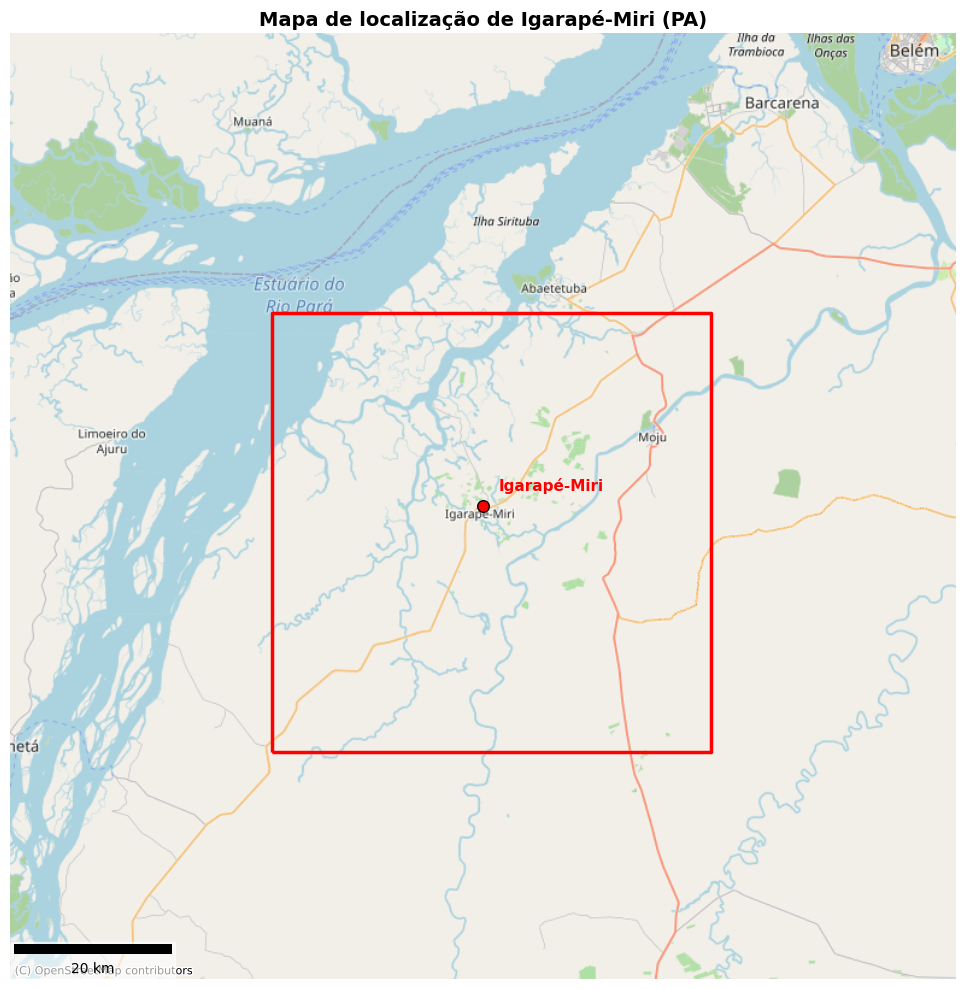

In [ ]:
# Instale as bibliotecas (caso necessário)
!pip install cartopy contextily geopandas matplotlib mercantile xyzservices matplotlib-scalebar

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# -----------------------------
# Coordenadas de Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

# Cria ponto
gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Converte para Web Mercator
gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.iloc[0]
y = gdf.geometry.y.iloc[0]

# -----------------------------
# QUADRADO (área do município)
# -----------------------------
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

quad = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# -----------------------------
# MAPA
# -----------------------------
fig, ax = plt.subplots(figsize=(10,10))

# Ponto
ax.scatter(
    x, y,
    color='red',
    s=70,
    edgecolor='black',
    zorder=5
)

ax.text(
    x + 2000,
    y + 2000,
    "Igarapé-Miri",
    fontsize=11,
    color='red',
    weight='bold'
)

# Quadrado do município
quad.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2.5,
    zorder=4
)

# Extensão do mapa
dist = 60000
ax.set_xlim(x - dist, x + dist)
ax.set_ylim(y - dist, y + dist)

# Fundo OSM
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# -----------------------------
# ESCALA DO MAPA
# -----------------------------
scalebar = ScaleBar(
    1,               # 1 pixel = 1 unidade do CRS (Web Mercator)
    units="m",
    dimension="si-length",
    location="lower left",
    box_alpha=0.6,
    color="black"
)

ax.add_artist(scalebar)

# -----------------------------
# Finalização
# -----------------------------
ax.set_axis_off()

plt.title(
    "Mapa de localização de Igarapé-Miri (PA)",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.savefig(
    "Mapa_Localizacao_Igarape_Miri_OSM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
quero o mapa acima com os meus dados coletados temperatura e evapotranspiração


SyntaxError: invalid syntax (2017504575.py, line 1)

### Plotando Dados Meteorológicos no Mapa de Igarapé-Miri

Agora, vamos integrar os dados de temperatura e evapotranspiração que coletamos e extraímos nos mapas geográficos de Igarapé-Miri. Para isso, precisaremos:

1.  **Carregar os dados** de temperatura e evapotranspiração dos arquivos NetCDF.
2.  **Converter a temperatura** de Kelvin para Celsius (se ainda não foi feito).
3.  **Definir uma função de plotagem** que utilize `geopandas` e `contextily` para criar a base do mapa e sobreponha os dados meteorológicos.
4.  **Chamar esta função** para plotar a temperatura e a evapotranspiração separadamente.

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar
import xarray as xr
import numpy as np
import os
import glob
import cartopy.crs as ccrs

# Coordenadas de Igarapé-Miri (reutilizando as do notebook)
lon_center = -48.96
lat_center = -1.97

# Extensão da área para o quadrado (reutilizando as do notebook)
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

# Caminhos para os diretórios de extração
et_data_dir = "/content/extracted_data/et_data"
temp_data_dir = "/content/extracted_data/temp_data"

In [ ]:
# --- Carregar e Pré-processar Dados de Temperatura ---

temp_files = sorted(glob.glob(os.path.join(temp_data_dir, "*Temperature-Air-2m*.nc")))

ds_temp = None
if temp_files:
    latest_temp_file = temp_files[-1] # Usar o arquivo mais recente
    print(f"Carregando dados de temperatura de: {latest_temp_file}")
    ds_temp = xr.open_dataset(latest_temp_file, engine='h5netcdf')

    # Identificar a variável de temperatura
    temp_var_name = None
    for var in ds_temp.data_vars:
        if 'temperature' in var.lower():
            temp_var_name = var
            break

    if temp_var_name:
        # Converter de Kelvin para Celsius (K - 273.15)
        ds_temp[temp_var_name] = ds_temp[temp_var_name] - 273.15
        print(f"Temperatura convertida para Celsius. Mín: {ds_temp[temp_var_name].min().item():.2f}°C, Máx: {ds_temp[temp_var_name].max().item():.2f}°C")
    else:
        print("Variável de temperatura não encontrada no dataset.")
else:
    print("Nenhum arquivo de temperatura encontrado.")


# --- Carregar e Pré-processar Dados de Evapotranspiração ---

et_files = sorted(glob.glob(os.path.join(et_data_dir, "*ReferenceET-PenmanMonteith-FAO56*.nc")))

ds_et = None
if et_files:
    latest_et_file = et_files[-1] # Usar o arquivo mais recente
    print(f"Carregando dados de evapotranspiração de: {latest_et_file}")
    ds_et = xr.open_dataset(latest_et_file, engine='h5netcdf')

    # Identificar a variável de evapotranspiração
    et_var_name = None
    for var in ds_et.data_vars:
        if 'referenceet' in var.lower():
            et_var_name = var
            break
    if et_var_name:
        print(f"Variável de evapotranspiração identificada: {et_var_name}")
    else:
        print("Variável de evapotranspiração não encontrada no dataset.")

else:
    print("Nenhum arquivo de evapotranspiração encontrado.")

Carregando dados de temperatura de: /content/extracted_data/temp_data/Temperature-Air-2m_Mean-24h_C3S-glob-agric_AgERA5_20250930_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
Temperatura convertida para Celsius. Mín: 27.32°C, Máx: 27.74°C
Carregando dados de evapotranspiração de: /content/extracted_data/et_data/ReferenceET-PenmanMonteith-FAO56_C3S-glob-agric_AgERA5_20250930_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc
Variável de evapotranspiração identificada: ReferenceET_PenmanMonteith_FAO56


In [ ]:
def plot_meteorological_data_on_map(data_array, title, cmap, unit, vmin=None, vmax=None):
    # Initialize the figure and GeoAxes with a Web Mercator projection for compatibility with contextily
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.Mercator()})

    # Cria ponto e quadrado para Igarapé-Miri
    # Note: These geometries are created in EPSG:4326 and then transformed to EPSG:3857 (Web Mercator)
    # which is the projection of the `ax` now.
    gdf_point = gpd.GeoDataFrame(geometry=[Point(lon_center, lat_center)], crs="EPSG:4326").to_crs(epsg=3857)
    x = gdf_point.geometry.x.iloc[0]
    y = gdf_point.geometry.y.iloc[0]

    quad_bbox = gpd.GeoDataFrame(geometry=[box(lon_min, lat_min, lon_max, lat_max)], crs="EPSG:4326").to_crs(epsg=3857)

    # Plotar o raster no mapa base
    x_coord_name = 'lon' if 'lon' in data_array.coords else 'longitude'
    y_coord_name = 'lat' if 'lat' in data_array.coords else 'latitude'

    if x_coord_name in data_array.coords and y_coord_name in data_array.coords:
        # Select the first timestamp for 2D plotting
        data_to_plot = data_array.isel(time=0)

        # Plot the raster data directly on the GeoAxes (ax).
        # Specify the transform as PlateCarree() because the data_to_plot's coordinates are in lat/lon.
        plot_handle = ax.pcolormesh(
            data_to_plot[x_coord_name],
            data_to_plot[y_coord_name],
            data_to_plot.values,
            cmap=cmap,
            transform=ccrs.PlateCarree(), # The CRS of the data coordinates
            vmin=vmin, vmax=vmax
        )

        # Add colorbar manually using the mappable returned by pcolormesh
        cbar = fig.colorbar(plot_handle, ax=ax, orientation='vertical', shrink=0.7, label=f'{title} ({unit})')

    else:
        print(f"Coordenadas '{x_coord_name}' ou '{y_coord_name}' não encontradas no dataset para plotagem.")
        return # Exit if coordinates are not found

    # Ponto
    # Plotting scatter points on a GeoAxes. The transform tells Cartopy the CRS of the points.
    ax.scatter(
        lon_center, lat_center,
        color='red',
        s=70,
        edgecolor='black',
        zorder=5,
        transform=ccrs.PlateCarree() # Specify the CRS of the scatter points
    )

    # Text (no transform needed if x, y are already in ax's CRS - EPSG:3857)
    ax.text(
        x + 2000,
        y + 2000,
        "Igarapé-Miri",
        fontsize=11,
        color='red',
        weight='bold',
        transform=ax.transData # Explicitly state the transform for clarity, it's already in the correct CRS
    )

    # Quadrado do município
    quad_bbox.boundary.plot(
        ax=ax,
        edgecolor="red",
        linewidth=2.5,
        zorder=4
    )

    # Extensão do mapa
    # Set extent using the coordinates of the Web Mercator projection
    ax.set_xlim(x - dist, x + dist)
    ax.set_ylim(y - dist, y + dist)

    # Fundo OSM - contextily works well with Web Mercator
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik
    )

    # Escala do mapa
    scalebar = ScaleBar(
        1,
        units="m",
        dimension="si-length",
        location="lower left",
        box_alpha=0.6,
        color="black"
    )
    ax.add_artist(scalebar)

    ax.set_axis_off()

    plt.title(f"{title} em Igarapé-Miri", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

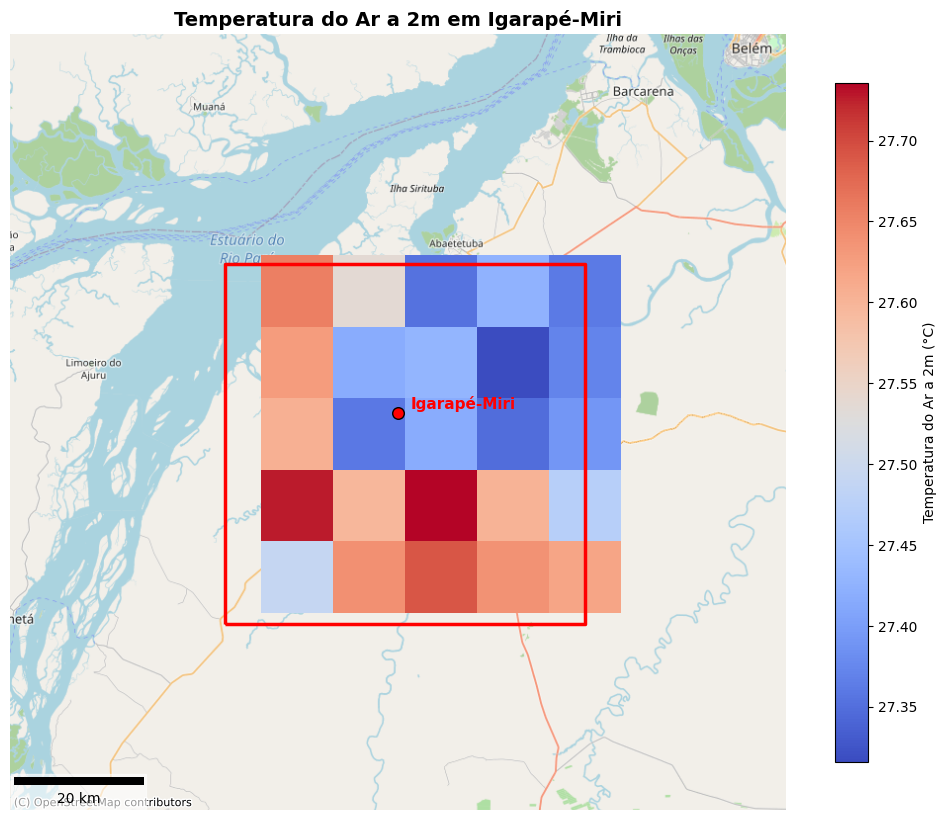

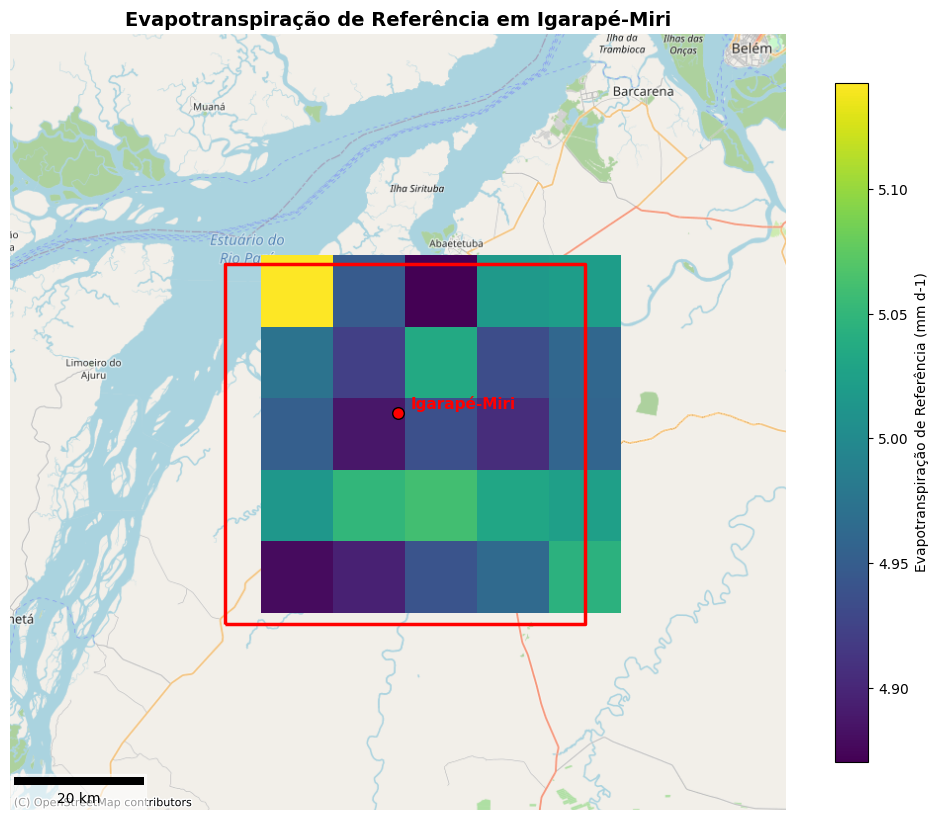

In [ ]:
if ds_temp and temp_var_name:
    # Determine min/max for consistent colorbar across plots if desired
    temp_min = ds_temp[temp_var_name].min().item()
    temp_max = ds_temp[temp_var_name].max().item()
    plot_meteorological_data_on_map(
        ds_temp[temp_var_name],
        "Temperatura do Ar a 2m",
        'coolwarm',
        '°C',
        vmin=temp_min, vmax=temp_max
    )
else:
    print("Não foi possível plotar a temperatura: dados não carregados ou variável não encontrada.")

if ds_et and et_var_name:
    et_min = ds_et[et_var_name].min().item()
    et_max = ds_et[et_var_name].max().item()
    plot_meteorological_data_on_map(
        ds_et[et_var_name],
        "Evapotranspiração de Referência",
        'viridis',
        'mm d-1',
        vmin=et_min, vmax=et_max
    )
else:
    print("Não foi possível plotar a evapotranspiração: dados não carregados ou variável não encontrada.")

In [4]:
!git init
!git add .
!git commit -m "Initial commit"
!git remote add origin https://github.com/maycongsouzaeng-pixel/LAMET-UENF-Maycon.git
!git branch -M main
!git push -u origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
